# Processing pipelines for visium Prostate cancer

This notebook prepares the human prostate cancer visium dataset and its paired single-cell RNA-seq reference for downstream reconstruction analyses.

The visium dataset is the **10x Genomics Human Prostate Cancer, Adenocarcinoma with Invasive Carcinoma (FFPE)** dataset analyzed with Space Ranger 1.3.0.


***
## Download the Visium dataset

The Visium data can be downloaded directly from the [10x Genomics dataset page](https://www.10xgenomics.com/datasets/human-prostate-cancer-adenocarcinoma-with-invasive-carcinoma-ffpe-1-standard-1-3-0).

The following commands download the H&E image, filtered feature-barcode matrix, and spatial output directly from 10x Genomics.


In [ ]:
%%bash

# Run from the FINER repository root, regardless of where Jupyter was launched.
PROJECT_ROOT="$(git rev-parse --show-toplevel 2>/dev/null)" || {
    echo "ERROR: Please run this notebook from inside a cloned FINER repository." >&2
    exit 1
}
cd "$PROJECT_ROOT"


mkdir -p data/Prostate/ST

cd data/Prostate/ST
wget "https://cf.10xgenomics.com/samples/spatial-exp/1.3.0/Visium_FFPE_Human_Prostate_Cancer/Visium_FFPE_Human_Prostate_Cancer_image.tif"
wget "https://cf.10xgenomics.com/samples/spatial-exp/1.3.0/Visium_FFPE_Human_Prostate_Cancer/Visium_FFPE_Human_Prostate_Cancer_filtered_feature_bc_matrix.h5"
wget "https://cf.10xgenomics.com/samples/spatial-exp/1.3.0/Visium_FFPE_Human_Prostate_Cancer/Visium_FFPE_Human_Prostate_Cancer_spatial.tar.gz"

tar -xzf Visium_FFPE_Human_Prostate_Cancer_spatial.tar.gz

## Download the single-cell reference

The single-cell reference is from Wu *et al.* and can be obtained from the [Broad Single Cell Portal (SCP1415)](https://singlecell.broadinstitute.org/single_cell/study/SCP1415/cryopreservation-of-human-cancers-conserves-tumour-heterogeneity-for-single-cell-multi-omics-analysis#study-download).

Download the following files into `data/Prostate/scRNA_reference/`:

- `Wu_etal_2021_allcells_barcodes.tsv`
- `Wu_etal_2021_allcells_genes.tsv`
- `Wu_etal_2021_allcells_raw_counts.mtx`
- `Wu_etal_2021_metadata.txt`

After downloading the datasets, the directory should look like:
```text
FINER/
└── data/
    └── Prostate/
        ├── ST/                               
        │   ├── Visium_FFPE_Human_Prostate_Cancer_image.tif
        │   ├── Visium_FFPE_Human_Prostate_Cancer_filtered_feature_bc_matrix.h5
        │   └── spatial/
        │       ├── tissue_positions_list.csv
        │       ├── scalefactors_json.json
        │       └── ...
        └── scRNA_reference/                   
            ├── Wu_etal_2021_allcells_barcodes.tsv
            ├── Wu_etal_2021_allcells_genes.tsv
            ├── Wu_etal_2021_allcells_raw_counts.mtx
            └── Wu_etal_2021_metadata.txt
```

***
## Preprocess the Visium data

We load the filtered 10x feature-barcode matrix and attach the full-resolution spatial coordinates from `tissue_positions_list.csv`.


In [1]:
import os
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse

def find_project_root(start=None):
    """Locate the FINER repository root without using machine-specific paths."""
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "finer").is_dir() and (candidate / "README.md").exists():
            return candidate
    raise RuntimeError(
        "FINER repository root not found. "
        "Please launch this notebook from inside the cloned FINER repository."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_DIR=Path("data/Prostate")
ST_DIR = Path("data/Prostate/ST")
SAMPLE = "Visium_FFPE_Human_Prostate_Cancer"


In [6]:
# Load the filtered Visium expression matrix
adata = sc.read_10x_h5(ST_DIR / f"{SAMPLE}_filtered_feature_bc_matrix.h5")

adata.var_names = adata.var_names.str.upper()
adata.var_names_make_unique()

position_columns = ["barcode","in_tissue","array_row","array_col","pxl_row_in_fullres","pxl_col_in_fullres"]

positions = pd.read_csv(
    ST_DIR / "spatial" / "tissue_positions_list.csv",
    header=None,
    names=position_columns,
    index_col="barcode",
)
positions = positions.loc[adata.obs_names]

adata.obsm["spatial"] = positions[["pxl_col_in_fullres", "pxl_row_in_fullres"]].to_numpy()
adata.obs[['pixel_x','pixel_y']]=adata.obsm["spatial"]
adata.var["genename"] = adata.var_names

adata.write_h5ad(DATA_DIR / "ST_adata.h5ad")

print(adata)


AnnData object with n_obs × n_vars = 4371 × 17943
    obs: 'pixel_x', 'pixel_y'
    var: 'gene_ids', 'feature_types', 'genome', 'genename'
    obsm: 'spatial'


***
## Preprocess the single-cell reference

The original preprocessing converted the complete 117,573-cell matrix to a dense array before subsetting. This is unnecessary and memory intensive. Here the count matrix remains sparse throughout preprocessing.


In [6]:
SC_DIR = Path("data/Prostate/scRNA_reference")

genes = pd.read_csv(SC_DIR / "Wu_etal_2021_allcells_genes.tsv",header=None,sep="\t").iloc[:, 0].astype(str)
barcodes = pd.read_csv(SC_DIR / "Wu_etal_2021_allcells_barcodes.tsv",header=None,sep="\t").iloc[:, 0].astype(str)

counts = sc.read_mtx(SC_DIR / "Wu_etal_2021_allcells_raw_counts.mtx").T
counts.var_names = genes.to_numpy()
counts.obs_names = barcodes.to_numpy()

meta = pd.read_csv(SC_DIR / "Wu_etal_2021_metadata.txt", sep="\t", index_col=0, low_memory=False)
meta = meta.loc[counts.obs_names].copy()

counts.obs = meta
print(counts)

AnnData object with n_obs × n_vars = 117573 × 29927
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'Condition', 'CellType', 'ClusterID'


In [7]:
# Harmonize the cell-type labels used in the prostate analysis
celltype_map = {
    "Cancer/Epithelial": "Cancer.Epithelial",
    "Monocytes/Macrophages": "Monocytes.Macrophages",
    "B-cells": "B.cells",
    "MAST cells": "MAST.cells",
    "NK cells": "NK.cells",
    "PVL cells": "PVL.cells",
    "T-cells": "T.cells",
}

prostate_celltypes = [
    "B.cells",
    "CAFs",
    "Cancer.Epithelial",
    "Endothelial",
    "MAST.cells",
    "Monocytes.Macrophages",
    "NK.cells",
    "PVL.cells",
    "T.cells",
]

counts.obs["cell_type"] = counts.obs["CellType"].replace(celltype_map)

keep = (
    counts.obs["organ__ontology_label"].eq("prostate gland")
    & counts.obs["cell_type"].isin(prostate_celltypes)
)

sc_adata = counts[keep].copy()

sc_adata.var_names = sc_adata.var_names.str.upper()
sc_adata.var_names_make_unique()

# Restrict to genes shared with the Visium dataset
shared_genes = adata.var_names.intersection(sc_adata.var_names)
sc_adata = sc_adata[:, shared_genes].copy()

sc_adata.obs["cell_id"] = sc_adata.obs_names
sc_adata.obs = sc_adata.obs[["cell_id", "cell_type"]].copy()

print(sc_adata)
print(sc_adata.obs["cell_type"].value_counts())

sc.pp.normalize_total(sc_adata, target_sum=1e4)
sc.pp.log1p(sc_adata)

sc_adata.write_h5ad(DATA_DIR / "sc_adata_log.h5ad")


AnnData object with n_obs × n_vars = 18075 × 16642
    obs: 'cell_id', 'cell_type'
cell_type
Cancer.Epithelial        10907
Endothelial               2437
T.cells                   1693
PVL.cells                 1293
CAFs                       710
Monocytes.Macrophages      633
NK.cells                   192
MAST.cells                 168
B.cells                     42
Name: count, dtype: int64



# Running FINER for Visium Prostate cancer

***
## Prerequisites & Environment Setup

Before running the pipeline, ensure all required packages are installed following the setup instructions in `README.md`.

### Download the pretrained checkpoints
FINER uses pretrained histology encoders from **HIPT** and **RetCCL** during image feature construction. These checkpoint files can be downloaded using the links below:

- **HIPT ViT-256:** [`vit256_small_dino.pth`](https://github.com/mahmoodlab/HIPT/raw/refs/heads/master/HIPT_4K/Checkpoints/vit256_small_dino.pth)
- **HIPT ViT-4K:** [`vit4k_xs_dino.pth`](https://github.com/mahmoodlab/HIPT/raw/refs/heads/master/HIPT_4K/Checkpoints/vit4k_xs_dino.pth)
- **RetCCL:** [`best_ckpt.pth`](https://drive.google.com/drive/folders/1AhstAFVqtTqxeS9WlBpU41BV08LYFUnL?usp=sharing)  

Open the RetCCL Google Drive folder and download `best_ckpt.pth`.
After downloading the checkpoints and completing the preprocessing for both single-cell and spatial transcriptomics data, the directory structure should look like this:

```text
FINER/
├── checkpoints/
│   ├── best_ckpt.pth
│   ├── vit4k_xs_dino.pth
│   └── vit256_small_dino.pth
└── data/
    └── Prostate/
        ├── ST/                               
        │   ├── Visium_FFPE_Human_Prostate_Cancer_image.tif
        │   ├── Visium_FFPE_Human_Prostate_Cancer_filtered_feature_bc_matrix.h5
        │   └── spatial/
        │       ├── tissue_positions_list.csv
        │       ├── scalefactors_json.json
        │       └── ...
        ├── ST_adata.h5ad                      # Preprocessed spatial transcriptomics data
        ├── scRNA_reference/                   
        │   ├── Wu_etal_2021_allcells_barcodes.tsv
        │   ├── Wu_etal_2021_allcells_genes.tsv
        │   ├── Wu_etal_2021_allcells_raw_counts.mtx
        │   └── Wu_etal_2021_metadata.txt
        └── sc_adata_log.h5ad                  # Preprocessed single-cell reference data
```

## Cellular Identity Reconstruction

FINER requires spot-level cell type proportion estimates as input. You can generate these deconvolution results using various tools (such as PANDA; please refer to the official PANDA tutorial https://github.com/Zhangxf-ccnu/PANDA-examples for step-by-step guidance). For this tutorial, the PANDA-based deconvolution results used in our analysis are provided in the accompanying [Zenodo archive](https://doi.org/10.5281/zenodo.22234790) located at `data/Prostate/deconv_results.csv`. Users may also use their own deconvolution results by saving the resulting proportion matrix as `deconv_results.csv` inside the corresponding sample folder (i.e., `./data/Prostate/deconv_results.csv`).

### Cellular Unit Identification

Before extracting image features, FINER requires single-cell centroid coordinates. While various cell segmentation tools can be seamlessly integrated into this pipeline, we demonstrate the workflow using [Cellpose](https://github.com/MouseLand/cellpose) (version 2.2.3) here. To handle large Whole Slide Images (WSIs), the image is dynamically tiled into patches, segmented, and the resulting cell centroids are mapped back to global pixel coordinates, saving the output as `cell_segmented_coords.csv`.

In [ ]:
%%bash
python -m finer.nuclei_segment \
    --tissue_name "Prostate" \
    --img_path "./data/Prostate/ST/Visium_FFPE_Human_Prostate_Cancer_image.tif" \
    --patch_size 5000 5000 \
    --diameter 10

### Image Feature Construction

This step processes the H&E image alongside cell segmentation coordinates to extract multi-scale visual embeddings via HIPT and RetCCL models.

In [ ]:
%%bash
python -m finer.feature_construction \
    --tissue_name "Prostate" \
    --img_path "./data/Prostate/ST/Visium_FFPE_Human_Prostate_Cancer_image.tif" \
    --spot_diameter_pixel 188.6 \
    --checkpoint_path "./checkpoints" 

### Cellular Identity Reconstruction

In [ ]:
%%bash
python -m finer.identity_reconstruction \
    --tissue_name "Prostate" \
    --spot_radius 94.3 

Through this cell-identity reconstruction proces, the predicted cellular identity assignment are obtained as shown below:

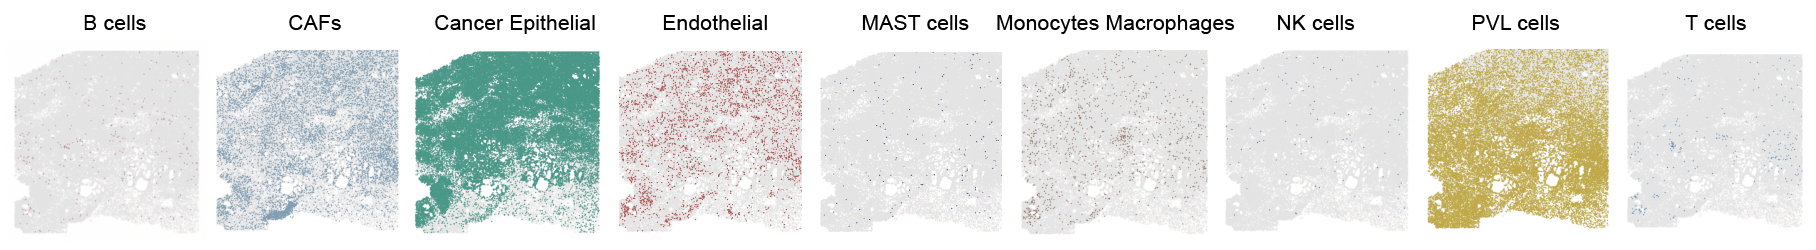

## Cellular Expression Reconstruction

Finally, FINER reconstructs tissue-wide cell-by-gene map using the cellular scaffold (`cellular_scaffold.h5ad`) obtained from `Cellular Identity Reconstruction`, log-transformed single-cell reference `sc_adata_log.h5ad`, spot-based spatialtranscriptome `ST_adata.h5ad`, and morphological features: `hipt_sub_feats.npy` and `resccl_feats.npy`. The output is saved as `finer_reconstructed.h5ad`.

In [ ]:
%%bash
python -m finer.expression_reconstruction \
    --tissue_name "Prostate" \
    --spot_radius 94.3 

Through the cellular expression reconstruction process， the reconstructed single- cell gene expression profiles are obtained as shown below：

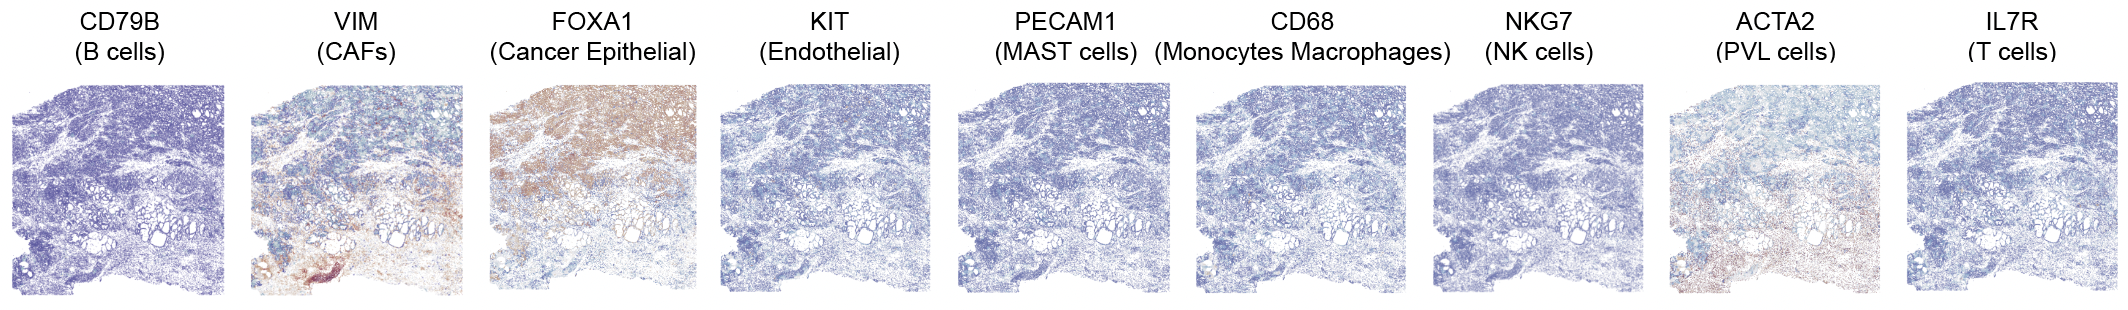

# Evaluation of cross-identity molecular attribution and its propagation into ligand–receptor inference

The script is organized as:
1) UMAP of reconstructed expression;
2) identity-specificity score;
3) marker leakage matrix;
4) source-type LR assignment similarity;
5) F1/Jaccard overlap;
6) sc-ref LR specificity;
7) representative LR directional support score.



***

In [ ]:
import os
import re
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
from statsmodels.stats.multitest import multipletests
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

**Shared gene universe**. To ensure a fair comparison across reconstruction methods, evaluations were restricted to genes available across FINER and all compared methods. The resulting shared gene set is provided in the accompanying [`Zenodo archive`](https://doi.org/10.5281/zenodo.22234790) as `data/Prostate/shared_benchmark_genes.csv`.


In [1]:
# ======================================================================
# GLOBAL SETTINGS AND INPUT/OUTPUT PATHS
# ======================================================================
RESULTS_DIR = "data/Prostate/"
PURITY_OUT_DIR = os.path.join(RESULTS_DIR, "purity")
CCI_OUT_DIR = os.path.join(RESULTS_DIR, "CCI_similarity")
os.makedirs(CCI_OUT_DIR, exist_ok=True)
os.makedirs(PURITY_OUT_DIR, exist_ok=True)

COMMON_GENE_FILE = os.path.join(RESULTS_DIR, "shared_benchmark_genes.csv")
SC_REF_FILE = os.path.join(RESULTS_DIR, "sc_adata_log.h5ad")

# Main FINER file
FINER_FILE = os.path.join(RESULTS_DIR,"finer_reconstructed.h5ad")

METHOD_NAME = "FINER"
method_order = [METHOD_NAME]

ligand = "COL4A1"
receptor = "CD44"

label_uniq = np.array([
    "B.cells", "CAFs", "Cancer.Epithelial", "Endothelial", "MAST.cells",
    "Monocytes.Macrophages", "NK.cells", "PVL.cells", "T.cells",
])

celltype_colors = {
    "B.cells": "#D97FA5",
    "CAFs": "#7FA9C2",
    "Cancer.Epithelial": "#12A792",
    "Endothelial": "#D35B5B",
    "MAST.cells": "#8B63C0",
    "Monocytes.Macrophages": "#9B7463",
    "NK.cells": "#5D79C8",
    "PVL.cells": "#D4B21F",
    "T.cells": "#4F95D1",
}

method_expr_already_log_norm = False
sc_ref_already_log_norm = True

n_perm = 500
min_expr_pct = 0.05
fdr_cutoff = 0.05
fdr_scope = "pair"
perm_random_seed = 1
eps = 1e-8

fdr_scope = "pair"
if fdr_scope == "global":
    sig_flag = "significant_global"
    fdr_col = "p_adj_global"
elif fdr_scope == "pair":
    sig_flag = "significant_pair"
    fdr_col = "p_adj_pair"
else:
    raise ValueError("fdr_scope must be 'global' or 'pair'")


# ======================================================================
# SHARED SETUP FOR MODULES 1-3: CELL-TYPE MARKER DEFINITION
# ======================================================================
common_genes = (pd.read_csv(COMMON_GENE_FILE, index_col=0)["0"].astype(str).values)

sc_adata = sc.read(SC_REF_FILE)
common_gene_set = set(common_genes)
sc_common_genes = [g for g in sc_adata.var_names if g in common_gene_set]
sc_adata = sc_adata[:, sc_common_genes].copy()

sc.tl.rank_genes_groups(sc_adata,groupby="cell_type",use_raw=False,method="wilcoxon")

rank_result = sc_adata.uns["rank_genes_groups"]
marker_tables = []

for group in rank_result["names"].dtype.names:
    df_group = pd.DataFrame({
        "cell_type": group,
        "gene": rank_result["names"][group],
        "logFC": rank_result["logfoldchanges"][group],
        "pval": rank_result["pvals"][group],
        "pval_adj": rank_result["pvals_adj"][group],
        "score": rank_result["scores"][group],
    })

    df_group = (
        df_group
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["gene", "logFC", "pval"])
    )
    df_group = df_group[(df_group["pval"] < 0.05) &(df_group["logFC"] > 1)].copy()
    df_group = df_group.sort_values("logFC",ascending=False).reset_index(drop=True)
    marker_tables.append(df_group)

marker_genes_df = pd.concat(marker_tables, axis=0, ignore_index=True)

# Preserve the original ordering step before selecting the top markers.
marker_genes_df = marker_genes_df.sort_values(by=["cell_type", "logFC"],ascending=[True, False]).copy()

marker_genes_df_top = (
    marker_genes_df
    .groupby("cell_type", group_keys=False)
    .head(100)
    .reset_index(drop=True)
)

# Keep only markers that occur in the top-100 list of exactly one cell type.
gene_counts = marker_genes_df_top["gene"].value_counts()
unique_genes = gene_counts[gene_counts == 1].index
marker_genes_df_unique = marker_genes_df_top[marker_genes_df_top["gene"].isin(unique_genes)].copy()

marker_dict = (marker_genes_df_unique.groupby("cell_type")["gene"].apply(list).to_dict())
marker_list = marker_genes_df_unique["gene"].values

print("Specific marker counts:")
print({k: len(v) for k, v in marker_dict.items()})


Specific marker counts:
{'B.cells': 45, 'CAFs': 92, 'Cancer.Epithelial': 100, 'Endothelial': 100, 'MAST.cells': 60, 'Monocytes.Macrophages': 66, 'NK.cells': 20, 'PVL.cells': 91, 'T.cells': 36}


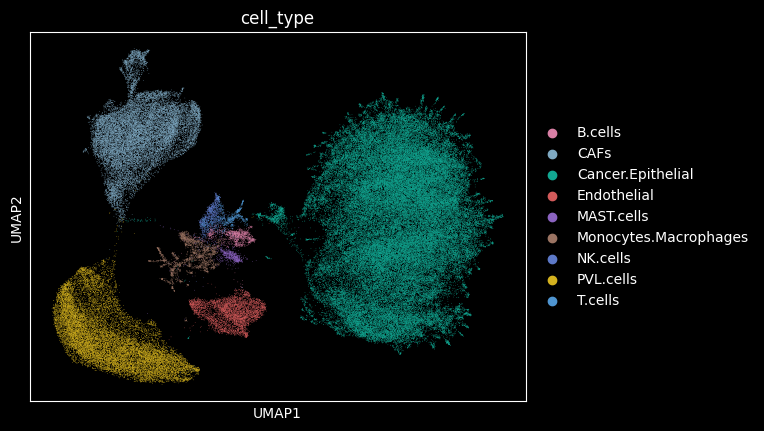

In [31]:
# ======================================================================
# MODULE 1. UMAP OF RECONSTRUCTED EXPRESSION
# ======================================================================
pc_adata = ad.read(FINER_FILE)
pc_adata.X=pc_adata.obsm['X_pred'].copy()
pc_adata = pc_adata[:, marker_list].copy()
pc_adata.uns["cell_type_colors"] = [celltype_colors[c] for c in label_uniq]

sc.tl.pca(pc_adata, svd_solver="arpack")
sc.pp.neighbors(pc_adata, n_neighbors=100, n_pcs=30)
sc.tl.umap(pc_adata, random_state=32)
sc.pl.umap(pc_adata,color='cell_type')

plt.show()


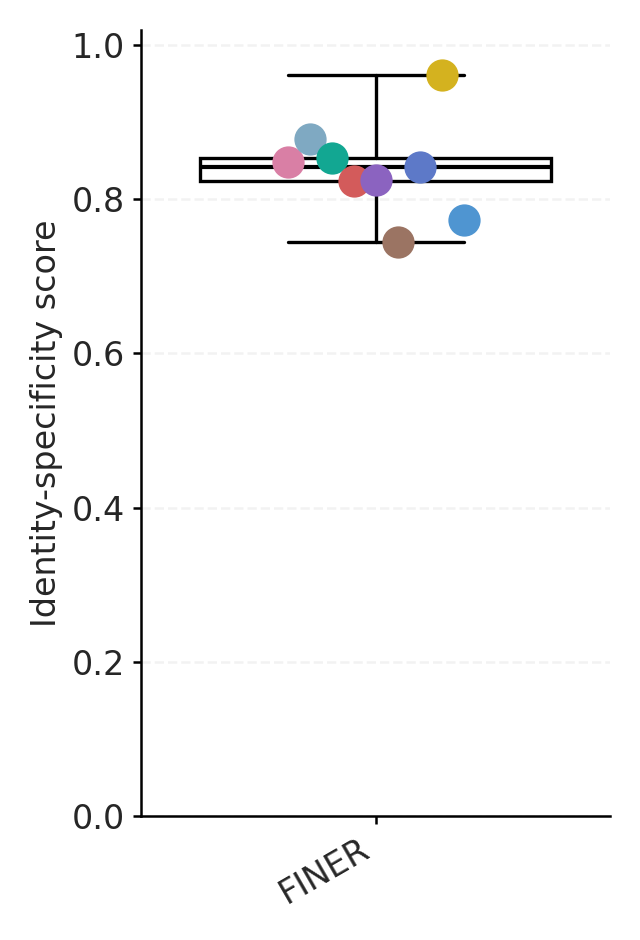

In [28]:
# ======================================================================
# MODULE 2. Identity-specificity score
# ======================================================================

def get_gene_sum_from_adata(adata, genes):
    """Return the per-cell sum of expression across the requested genes."""
    valid_genes = [g for g in genes if g in adata.var_names]
    if len(valid_genes) == 0:
        return pd.Series(0.0, index=adata.obs_names)
    X_sub = adata[:, valid_genes].X
    if sp.issparse(X_sub):
        vals = np.asarray(X_sub.sum(axis=1)).flatten()
    else:
        vals = np.asarray(X_sub).sum(axis=1).flatten()

    return pd.Series(vals, index=adata.obs_names).fillna(0.0)

pred_adata = ad.read_h5ad(FINER_FILE)
pred_adata = pred_adata[:, marker_list].copy()
sc.pp.normalize_total(pred_adata, target_sum=1e4)
pred_adata.obs_names_make_unique()

marker_sum_df = pd.DataFrame(index=pred_adata.obs_names)
for ct, genes in marker_dict.items():
    marker_sum_df[ct] = get_gene_sum_from_adata(pred_adata, genes)

pred_cell_type = pred_adata.obs["cell_type"].astype(str).values
native_marker_expr = np.zeros(pred_adata.n_obs, dtype=float)
foreign_marker_expr = np.zeros(pred_adata.n_obs, dtype=float)
purity = np.zeros(pred_adata.n_obs, dtype=float)

all_marker_cts = list(marker_sum_df.columns)
marker_lengths = {ct: len(genes) for ct, genes in marker_dict.items()
}

for i, ct_pred in enumerate(pred_cell_type):
    if ct_pred in marker_sum_df.columns:
        native_sum = marker_sum_df.iloc[i][ct_pred]
        native_count = marker_lengths[ct_pred]
    else:
        native_sum = 0.0
        native_count = 1

    foreign_cts = [ct for ct in all_marker_cts if ct != ct_pred]
    
    if len(foreign_cts) > 0:
        foreign_sum = marker_sum_df.iloc[i][foreign_cts].sum()
        foreign_count = sum(
            marker_lengths[ct]
            for ct in foreign_cts
        )
    else:
        foreign_sum = 0.0
        foreign_count = 1

    native_mean = native_sum / native_count
    foreign_mean = foreign_sum / foreign_count

    native_marker_expr[i] = native_mean
    foreign_marker_expr[i] = foreign_mean

    marker_pool_total = native_mean + foreign_mean
    if marker_pool_total == 0 or np.isnan(marker_pool_total):
        purity[i] = np.nan
    else:
        purity[i] = native_mean / marker_pool_total

purity = np.clip(purity, 0, 1)
purity_safe = np.nan_to_num(purity, nan=0.0)

pred_adata.obs["native_marker_mean"] = native_marker_expr
pred_adata.obs["foreign_marker_mean"] = foreign_marker_expr
pred_adata.obs["purity"] = purity_safe

# Use the in-memory purity values directly; no intermediate CSV round-trip.
purity_plot_df = pred_adata.obs[["cell_type", "purity"]].copy()
purity_plot_df["cell_type"] = (purity_plot_df["cell_type"].astype(str))
purity_plot_df["method"] = METHOD_NAME
purity_plot_df = purity_plot_df.dropna(
    subset=["cell_type", "purity"]
).reset_index(drop=True)

purity_method_order = [METHOD_NAME]
actual_cells = purity_plot_df["cell_type"].unique()
purity_celltype_order = sorted([
    ct for ct in celltype_colors
    if ct in actual_cells
])

type_mean_df = (purity_plot_df.groupby(["method", "cell_type"])["purity"].mean().reset_index(name="purity_mean"))
type_mean_df["method"] = pd.Categorical(type_mean_df["method"],categories=purity_method_order,ordered=True)
type_mean_df["cell_type"] = pd.Categorical(type_mean_df["cell_type"],categories=purity_celltype_order,ordered=True)
type_mean_df = (type_mean_df.sort_values(["method", "cell_type"]).reset_index(drop=True))

purity_save_file = os.path.join(PURITY_OUT_DIR,"benchmarking_purity_boxplot.pdf")

with mpl.rc_context():
    plt.rcParams.update({
        "font.size": 6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(2, 3),dpi=300)
    method_x = np.arange(len(purity_method_order))
    box_data = []

    for method in purity_method_order:
        vals = (type_mean_df
            .loc[type_mean_df["method"].astype(str) == method,"purity_mean"]
            .dropna().astype(float).values)
        box_data.append(vals)

    box_width = 0.75
    bp = ax.boxplot(
        box_data,
        positions=method_x,
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        whis=(0, 100),
        zorder=2,
    )

    for box in bp["boxes"]:
        box.set(facecolor=(1, 1, 1, 0.0),edgecolor="black",linewidth=0.8)
    for median in bp["medians"]:
        median.set(color="black",linewidth=1.0)
    for whisker in bp["whiskers"]:
        whisker.set(color="black",linewidth=0.8)
    for cap in bp["caps"]:
        cap.set(color="black",linewidth=0.8)

    point_offsets = np.linspace(-box_width * 0.25,box_width * 0.25,len(purity_celltype_order))

    for m_idx, method in enumerate(purity_method_order):
        sub = type_mean_df[type_mean_df["method"].astype(str) == method].copy()
        sub = (sub.set_index("cell_type").reindex(purity_celltype_order).reset_index())
        for i, row in sub.iterrows():
            if pd.isna(row["purity_mean"]):
                continue

            ct = str(row["cell_type"])
            ax.scatter(
                method_x[m_idx] + point_offsets[i],
                row["purity_mean"],
                s=60,
                marker="o",
                facecolor=celltype_colors.get(ct, "#333333"),
                edgecolor="black",
                linewidth=0,
                alpha=1,
                zorder=5,
                clip_on=False,
            )

    ax.set_xticks(method_x)
    ax.set_xticklabels(purity_method_order,rotation=30,ha="right")
    ax.set_ylabel("Identity-specificity score",fontsize=8,labelpad=2)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.02)
    ax.grid(axis="y",linestyle="--",alpha=0.25,linewidth=0.6)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    ax.tick_params(axis="x",which="major",bottom=True,top=False,length=2,width=0.6,color="black",labelsize=8,pad=2)
    ax.tick_params(axis="y",which="major",left=True,right=False,length=2,width=0.6,color="black",labelsize=8,pad=2)

    plt.tight_layout(pad=0.2)
    plt.savefig(purity_save_file,dpi=300,bbox_inches="tight",transparent=True)

plt.show()


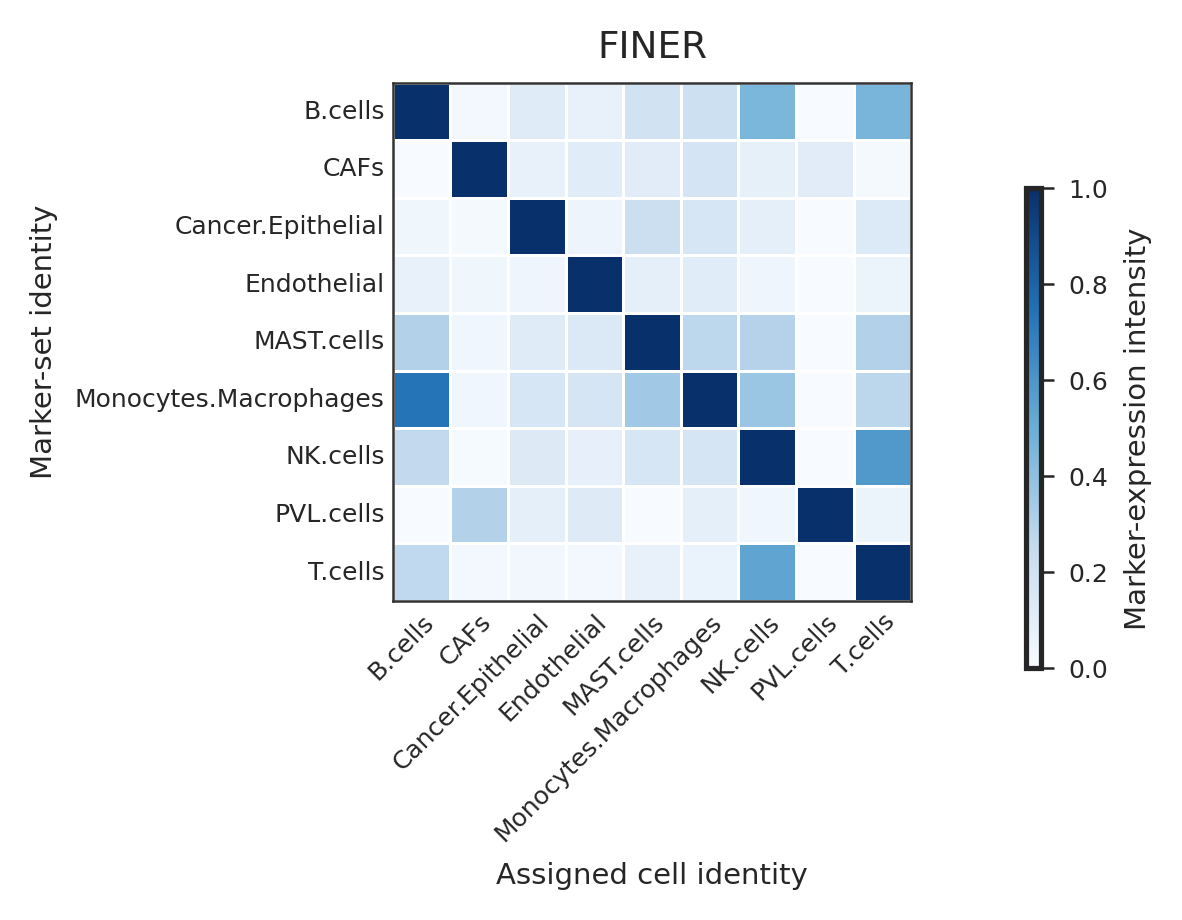

In [8]:

# ======================================================================
# MODULE 3. MARKER LEAKAGE MATRIX
# ======================================================================

def safe_subset_genes(adata, genes):
    genes = [str(g) for g in genes]
    var_set = set(adata.var_names.astype(str))
    return [
        g for g in genes
        if g in var_set
    ]

def get_marker_module_score(adata, genes):
    valid_genes = safe_subset_genes(adata, genes)
    if len(valid_genes) == 0:
        return pd.Series(0.0, index=adata.obs_names)
    X_sub = adata[:, valid_genes].X
    if sp.issparse(X_sub):
        vals = np.asarray(X_sub.mean(axis=1)).flatten()
    else:
        vals = np.asarray(X_sub).mean(axis=1).flatten()
    vals = np.nan_to_num(vals,nan=0.0,posinf=0.0,neginf=0.0,)
    return pd.Series(vals, index=adata.obs_names)


def prepare_leakage_adata(file_path, marker_genes):
    adata = ad.read_h5ad(file_path)
    adata.var_names = adata.var_names.astype(str)
    adata.obs_names_make_unique()
    adata.obs["cell_type"] = (adata.obs["cell_type"].astype(str).values)

    valid_markers = safe_subset_genes(adata,marker_genes)
    if len(valid_markers) == 0:
        raise ValueError(
            "No marker genes found in FINER adata.var_names."
        )

    adata = adata[:, valid_markers].copy()
    sc.pp.normalize_total(adata,target_sum=1e4)
    return adata

def compute_leakage_matrix(
    adata,
    marker_dict,
    celltype_order=None,
    min_cells=5,
):
    cell_type = adata.obs["cell_type"].astype(str)
    marker_source_order = list(marker_dict.keys())

    if celltype_order is None:
        celltype_order = sorted(
            cell_type.unique().tolist()
        )

    marker_score_df = pd.DataFrame(index=adata.obs_names)
    for marker_type, genes in marker_dict.items():
        marker_score_df[marker_type] = (get_marker_module_score(adata,genes))

    matrix = pd.DataFrame(index=marker_source_order,columns=celltype_order,dtype=float,)
    ncell_matrix = pd.DataFrame(index=marker_source_order,columns=celltype_order,dtype=float)

    for ct in celltype_order:
        idx = cell_type == ct
        n_cells = int(idx.sum())

        if n_cells < min_cells:
            matrix.loc[:, ct] = np.nan
            ncell_matrix.loc[:, ct] = n_cells
            continue

        matrix.loc[:, ct] = (
            marker_score_df
            .loc[idx.values, marker_source_order]
            .mean(axis=0)
            .values
        )
        ncell_matrix.loc[:, ct] = n_cells

    return matrix, ncell_matrix


def row_minmax_scale(mat):
    """Apply row-wise min-max scaling for leakage visualization."""
    scaled = mat.copy().astype(float)

    for idx in scaled.index:
        row = scaled.loc[idx].astype(float)
        row_min = np.nanmin(row.values)
        row_max = np.nanmax(row.values)

        if (
            np.isnan(row_min) or
            np.isnan(row_max) or
            row_max == row_min
        ):
            scaled.loc[idx] = 0.0
        else:
            scaled.loc[idx] = ((row - row_min) /(row_max - row_min))

    return scaled


marker_common_df = marker_genes_df_unique[marker_genes_df_unique["gene"].astype(str).isin(common_gene_set)].copy()
marker_common_df["gene"] = (marker_common_df["gene"].astype(str))
marker_common_df["assigned_type"] = (
    marker_common_df["cell_type"]
    .astype(str)
)
leakage_marker_dict = (
    marker_common_df
    .groupby("assigned_type")["gene"]
    .apply(lambda x: sorted(set(x.astype(str))))
    .to_dict()
)
leakage_marker_list = sorted(
    set(marker_common_df["gene"].dropna().astype(str).tolist())
)
global_celltype_order = sorted(leakage_marker_dict.keys())

leakage_adata = prepare_leakage_adata(FINER_FILE,leakage_marker_list)
leakage_raw_mat, leakage_ncell_mat = (
    compute_leakage_matrix(
        adata=leakage_adata,
        marker_dict=leakage_marker_dict,
        celltype_order=global_celltype_order,
        min_cells=1,
    )
)
leakage_plot_mat = row_minmax_scale(leakage_raw_mat)
leakage_save_pdf = os.path.join(PURITY_OUT_DIR,"marker_leakage_matrix.pdf",)

with mpl.rc_context():
    plt.rcParams.update({
        "font.size": 7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })
    sns.set_theme(style="white")

    leakage_cmap = LinearSegmentedColormap.from_list(
        "leakage_cmap",["#F7FBFF","#C6DBEF","#6BAED6","#2171B5","#08306B",],
    )

    fig, axes = plt.subplots(nrows=1,ncols=1,figsize=(3.2, 3.2),dpi=300,sharex=False,sharey=True,)
    axes = np.atleast_1d(axes)
    ax = axes[0]

    mat_plot = leakage_plot_mat.loc[global_celltype_order,global_celltype_order]
    sns.heatmap(
        mat_plot,
        ax=ax,
        cmap=leakage_cmap,
        vmin=0,
        vmax=1,
        square=True,
        linewidths=0.35,
        linecolor="white",
        cbar=False,
        xticklabels=True,
        yticklabels=True,
    )
    ax.set_title(METHOD_NAME,fontsize=9,pad=6)

    ax.set_xlabel("Assigned cell identity",fontsize=7,labelpad=4)
    ax.set_ylabel("Marker-set identity",fontsize=7)

    ax.set_xticklabels(mat_plot.columns,rotation=45,ha="right",rotation_mode="anchor",fontsize=6,)
    ax.set_yticklabels(mat_plot.index,rotation=0,fontsize=6)

    ax.tick_params(axis="x",length=0,pad=2)
    ax.tick_params(axis="y",length=0,pad=2)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.6)
        spine.set_color("#333333")

    cbar_ax = fig.add_axes([0.92,0.25,0.015,0.50])
    norm = plt.Normalize(vmin=0,vmax=1)
    sm = plt.cm.ScalarMappable(cmap=leakage_cmap,norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm,cax=cbar_ax)
    cbar.set_label("Marker-expression intensity",fontsize=7)

    cbar.ax.tick_params(labelsize=6,width=0.6,length=3,)
    plt.subplots_adjust(left=0.18,right=0.88,bottom=0.32,top=0.86,)
    plt.savefig(leakage_save_pdf,dpi=300,bbox_inches="tight",)

plt.show()

**Ligand–receptor database.** The ligand–receptor (LR) interactions used below are derived from the human CellChatDB interaction database.

Because CellChatDB is actively maintained, the current GitHub version may differ slightly from the frozen database used for the reported results. For exact numerical reproduction, use the human interaction database provided in the accompanying [Zenodo archive](https://doi.org/10.5281/zenodo.22234790), located at `data/Prostate/CellChatDB_use_interaction_human.csv`.

Users who prefer to use the latest CellChatDB can retrieve the current human interaction database directly from the CellChat GitHub repository and retain the three protein-signaling categories used in this analysis:

In [ ]:
# obtain the latest CellChatDB
from pathlib import Path
import requests
import rdata

url = ("https://github.com/jinworks/CellChat/raw/main/data/CellChatDB.human.rda")
rda_path = Path("CellChatDB.human.rda")

response = requests.get(url, timeout=120)
response.raise_for_status()
rda_path.write_bytes(response.content)

parsed = rdata.parser.parse_file(rda_path)
converted = rdata.conversion.convert(parsed)

cellchat_db = converted["CellChatDB.human"]
interaction = cellchat_db["interaction"]

interaction_use = interaction[
    interaction["annotation"].isin(["Secreted Signaling", "ECM-Receptor", "Cell-Cell Contact"])
].copy()

interaction_use.to_csv(os.path.join(RESULTS_DIR, "CellChatDB_use_interaction_human_latest.csv"),index=False)

In [ ]:
# ======================================================================
# MODULE 4. SOURCE-TYPE LR ASSIGNMENT SIMILARITY
# ======================================================================
# load SHARED LR-GENE UNIVERSE
LR_DB_FILE=os.path.join(RESULTS_DIR, "CellChatDB_use_interaction_human.csv")
lr_df = pd.read_csv(LR_DB_FILE)

possible_ligand_cols = ["ligand", "Ligand", "ligand_gene", "ligand_symbol"]
possible_receptor_cols = ["receptor", "Receptor", "receptor_gene", "receptor_symbol"]
ligand_col = next((c for c in possible_ligand_cols if c in lr_df.columns), None)
receptor_col = next((c for c in possible_receptor_cols if c in lr_df.columns), None)

def split_lr_genes(x):
    """Split a ligand/receptor complex into individual gene symbols."""
    if pd.isna(x):
        return []
    return [p.strip() for p in re.split(r"[_;&|,+/]", str(x).strip()) if p.strip()]

def all_genes_in_set(x, gene_set):
    genes = split_lr_genes(x)
    return len(genes) > 0 and all(g in gene_set for g in genes)

lr_genes = set()
for x in lr_df[ligand_col].dropna():
    lr_genes.update(split_lr_genes(x))
for x in lr_df[receptor_col].dropna():
    lr_genes.update(split_lr_genes(x))
lr_genes = sorted(lr_genes)

COMMON_GENE_ALL_FILE=os.path.join(RESULTS_DIR, "lr_genes_common_all.csv")

lr_genes_common = sorted(common_gene_set & set(lr_genes))
print("LR common genes:", len(lr_genes_common))
pd.DataFrame(lr_genes_common).to_csv(COMMON_GENE_ALL_FILE)

gene_set = set(lr_genes_common)
lr_df_use = lr_df[
    lr_df[ligand_col].apply(lambda x: all_genes_in_set(x, gene_set))
    & lr_df[receptor_col].apply(lambda x: all_genes_in_set(x, gene_set))
].copy()
print("Original LR pairs:", lr_df.shape[0])
print("Usable LR pairs:", lr_df_use.shape[0])

# ======================================================================
# SIGNIFICANT LR INFERENCE BY PERMUTATION TEST
# ======================================================================

def get_molecule_genes(molecule):
    """
    CellChat complex:
        ITGA5_ITGB1 -> [ITGA5, ITGB1]
    """
    if pd.isna(molecule):
        return []

    molecule = str(molecule).strip().replace(" ", "")

    if molecule == "":
        return []

    return molecule.split("_")


def molecule_in_gene_set(molecule, gene_set):
    genes = get_molecule_genes(molecule)
    return len(genes) > 0 and all(g in gene_set for g in genes)


def get_molecule_expr_matrix_from_adata(adata, molecules):

    var_names = pd.Index(adata.var_names.astype(str).str.upper())
    gene_to_idx = {g: i for i, g in enumerate(var_names)}
    X = adata.X

    mol_expr = {}
    missing_molecules = []

    for mol in molecules:
        mol_upper = str(mol).upper()
        genes = get_molecule_genes(mol_upper)
        genes = [g.upper() for g in genes]

        if len(genes) == 0:
            missing_molecules.append(mol_upper)
            continue

        if not all(g in gene_to_idx for g in genes):
            missing_molecules.append(mol_upper)
            continue

        idx = [gene_to_idx[g] for g in genes]

        if len(idx) == 1:
            vals = X[:, idx[0]]
            if sp.issparse(vals):
                vals = vals.toarray().ravel()
            else:
                vals = np.asarray(vals).ravel()

        else:
            X_sub = X[:, idx]
            if sp.issparse(X_sub):
                X_sub = X_sub.toarray()
            else:
                X_sub = np.asarray(X_sub)
            vals = X_sub.min(axis=1)

        mol_expr[mol_upper] = vals.astype(np.float32)

    mol_expr_df = pd.DataFrame(mol_expr,index=adata.obs_names)

    return mol_expr_df, missing_molecules


def compute_group_mean_and_pct(mol_expr_df, labels, celltype_order, expr_threshold=0):
    """
    Compute mean expression and expressing fraction for each molecule × cell type.
    """
    labels = pd.Series(labels, index=mol_expr_df.index).astype(str)

    mean_dict = {}
    pct_dict = {}

    for ct in celltype_order:
        idx = labels.values == ct
        if idx.sum() == 0:
            continue

        X_ct = mol_expr_df.loc[idx, :]
        mean_dict[ct] = X_ct.mean(axis=0).values
        pct_dict[ct] = (X_ct > expr_threshold).mean(axis=0).values

    mean_df = pd.DataFrame(mean_dict,index=mol_expr_df.columns)
    pct_df = pd.DataFrame(pct_dict,index=mol_expr_df.columns)

    return mean_df, pct_df


def compute_lr_scores_from_molecule_tables(
    mol_mean_df,
    mol_pct_df,
    lr_df,
    celltype_order,
    method_name,
    score_col="LR_score"
):
    """
    Compute all source-target LR scores from molecule mean and pct tables.
    """
    records = []

    available_celltypes = [ct for ct in celltype_order if ct in mol_mean_df.columns]

    lr_tmp = lr_df.copy()
    lr_tmp["ligand"] = lr_tmp["ligand"].astype(str).str.upper()
    lr_tmp["receptor"] = lr_tmp["receptor"].astype(str).str.upper()
    lr_tmp["interaction_name"] = lr_tmp["interaction_name"].astype(str)

    lr_tmp = lr_tmp[
        lr_tmp["ligand"].isin(mol_mean_df.index) &
        lr_tmp["receptor"].isin(mol_mean_df.index)
    ].copy()

    for source in available_celltypes:
        for target in available_celltypes:
            ligand_expr = lr_tmp["ligand"].map(mol_mean_df[source]).astype(float)
            receptor_expr = lr_tmp["receptor"].map(mol_mean_df[target]).astype(float)

            ligand_pct = lr_tmp["ligand"].map(mol_pct_df[source]).astype(float)
            receptor_pct = lr_tmp["receptor"].map(mol_pct_df[target]).astype(float)

            lr_score = ligand_expr.values * receptor_expr.values

            df_pair = lr_tmp.copy()
            df_pair["method"] = method_name
            df_pair["source"] = source
            df_pair["target"] = target
            df_pair["ligand_expr_source"] = ligand_expr.values
            df_pair["receptor_expr_target"] = receptor_expr.values
            df_pair["source_ligand_pct"] = ligand_pct.values
            df_pair["target_receptor_pct"] = receptor_pct.values
            df_pair[score_col] = lr_score

            records.append(df_pair)

    score_df = pd.concat(records, axis=0, ignore_index=True)
    score_df = score_df[score_df[score_col].notna()].copy()

    return score_df


def add_fdr_columns(df, fdr_scope="global"):
    """
    Add BH-FDR adjusted p-values.

    """
    out = df.copy()

    if fdr_scope in ["global", "both"]:
        out["p_adj_global"] = multipletests(
            out["p_value"].astype(float).values,method="fdr_bh"
        )[1]

    if fdr_scope in ["pair", "both"]:
        out["p_adj_pair"] = np.nan

        for (source, target), idx in out.groupby(["source", "target"]).groups.items():
            pvals = out.loc[idx, "p_value"].astype(float).values
            out.loc[idx, "p_adj_pair"] = multipletests(pvals,method="fdr_bh"
            )[1]

    return out

def summarize_significant_lr(sig_df, method_name, fdr_col):
    rows = []

    for (source, target), sub in sig_df.groupby(["source", "target"]):
        rows.append({
            "method": method_name,
            "source": source,
            "target": target,
            "n_sig_LR": sub.shape[0],
            "sum_sig_LR_score": sub["LR_score"].sum(),
            "max_sig_LR_score": sub["LR_score"].max(),
            "median_sig_LR_score": sub["LR_score"].median(),
            "min_fdr": sub[fdr_col].min()
        })

    return pd.DataFrame(rows)


def permutation_test_lr_scores(
    mol_expr_df,
    labels,
    lr_df,
    celltype_order,
    method_name,
    n_perm=500,
    min_expr_pct=0.05,
    random_seed=1,
    expr_threshold=0,
):
    rng = np.random.default_rng(random_seed)

    labels = np.asarray(pd.Series(labels).astype(str).values)
    mol_expr_df = mol_expr_df.copy()
    mol_expr_df.columns = mol_expr_df.columns.astype(str).str.upper()

    # observed mean / pct
    mol_mean_df, mol_pct_df = compute_group_mean_and_pct(
        mol_expr_df=mol_expr_df,
        labels=labels,
        celltype_order=celltype_order,
        expr_threshold=expr_threshold
    )

    obs_df = compute_lr_scores_from_molecule_tables(
        mol_mean_df=mol_mean_df,
        mol_pct_df=mol_pct_df,
        lr_df=lr_df,
        celltype_order=celltype_order,
        method_name=method_name,
        score_col="LR_score"
    )

    obs_df["pass_expr_pct"] = (
        (obs_df["source_ligand_pct"] >= min_expr_pct) &
        (obs_df["target_receptor_pct"] >= min_expr_pct) &
        (obs_df["LR_score"] > 0)
    )

    mol_names = mol_mean_df.index.astype(str).str.upper().tolist()
    ct_names = mol_mean_df.columns.astype(str).tolist()

    mol_to_idx = {m: i for i, m in enumerate(mol_names)}
    ct_to_idx = {c: i for i, c in enumerate(ct_names)}

    lig_idx = obs_df["ligand"].astype(str).str.upper().map(mol_to_idx).astype(int).values
    rec_idx = obs_df["receptor"].astype(str).str.upper().map(mol_to_idx).astype(int).values
    src_idx = obs_df["source"].astype(str).map(ct_to_idx).astype(int).values
    tgt_idx = obs_df["target"].astype(str).map(ct_to_idx).astype(int).values

    obs_scores = obs_df["LR_score"].astype(float).values
    n_tests = obs_df.shape[0]
    exceed_count = np.zeros(n_tests, dtype=np.int32)

    X = mol_expr_df.loc[:, mol_names].values.astype(np.float32)

    # ------------------------------------------------------------
    # permutation
    # ------------------------------------------------------------
    for p in range(n_perm):
        if (p + 1) % 50 == 0:
            print(f"{method_name}: permutation {p + 1}/{n_perm}")

        perm_labels = rng.permutation(labels)
        perm_mean = np.zeros((len(mol_names), len(ct_names)), dtype=np.float32)

        for j, ct in enumerate(ct_names):
            idx = perm_labels == ct
            if idx.sum() > 0:
                perm_mean[:, j] = X[idx, :].mean(axis=0)

        perm_scores = (perm_mean[lig_idx, src_idx] * perm_mean[rec_idx, tgt_idx])
        exceed_count += (perm_scores >= obs_scores).astype(np.int32)

    obs_df["p_value"] = (exceed_count + 1.0) / (n_perm + 1.0)
    obs_df.loc[~obs_df["pass_expr_pct"], "p_value"] = 1.0

    return obs_df


# -----------------------------
# Load common genes
# -----------------------------

common_gene = (
    pd.read_csv(COMMON_GENE_FILE, index_col=0)
    .iloc[:, 0]
    .astype(str)
    .str.upper()
    .tolist()
)
common_gene_set = set(common_gene)

# -----------------------------
# Filter CellChatDB to covered LR pairs
# -----------------------------

lr_db = pd.read_csv(LR_DB_FILE)

required_cols = ["ligand", "receptor"]
missing = [c for c in required_cols if c not in lr_db.columns]

if len(missing) > 0:
    raise ValueError(f"LR database missing columns: {missing}")

lr_db["ligand"] = lr_db["ligand"].astype(str).str.upper()
lr_db["receptor"] = lr_db["receptor"].astype(str).str.upper()

if "interaction_name" not in lr_db.columns:
    lr_db["interaction_name"] = lr_db["ligand"] + "_" + lr_db["receptor"]

lr_use = lr_db[
    lr_db["ligand"].apply(lambda x: molecule_in_gene_set(x, common_gene_set)) &
    lr_db["receptor"].apply(lambda x: molecule_in_gene_set(x, common_gene_set))
].copy()

lr_use = lr_use.drop_duplicates(subset=["ligand", "receptor", "interaction_name"]).copy()

print("Candidate LR pairs covered by common genes:", lr_use.shape[0])

lr_use.to_csv(
    os.path.join(CCI_OUT_DIR, "LR_pairs_covered_by_common_genes.csv"),
    index=False
)


def prepare_finer_adata(common_gene, expr_already_log_norm=False):
    """Load and preprocess FINER for LR permutation testing."""
    print(f"\nLoading {METHOD_NAME}: {FINER_FILE}")
    adata = ad.read(FINER_FILE)
    adata.obs_names_make_unique()

    adata.var_names = adata.var_names.astype(str).str.upper()
    if adata.var_names.duplicated().sum() > 0:
        print(
            METHOD_NAME,
            "duplicated genes after upper-case:",
            int(adata.var_names.duplicated().sum()),
        )
        adata = adata[:, ~adata.var_names.duplicated()].copy()

    common_gene_use = [g.upper() for g in common_gene]
    common_gene_use = [g for g in common_gene_use if g in adata.var_names]
    print(METHOD_NAME, "common genes used:", len(common_gene_use))
    if len(common_gene_use) == 0:
        raise ValueError(f"No common genes found in {METHOD_NAME}.")
    adata = adata[:, common_gene_use].copy()

    if "cell_type" not in adata.obs.columns:
        raise ValueError(f"{METHOD_NAME} adata.obs must contain column 'cell_type'.")
    adata.obs["cell_type"] = adata.obs["cell_type"].astype(str).values

    if not expr_already_log_norm:
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
    else:
        print(f"{METHOD_NAME}: use existing log-normalized expression; skip normalize/log1p.")

    if "spatial" in adata.obsm_keys():
        adata.obs[["pixel_x", "pixel_y"]] = adata.obsm["spatial"][:, [1, 0]]

    return adata


# ============================================================
# Permutation-test based significant LR analysis
# ============================================================
# ligand/receptor molecule
lr_molecules = sorted(
    set(lr_use["ligand"].astype(str).str.upper()) |
    set(lr_use["receptor"].astype(str).str.upper())
)

print("Molecules used for permutation test:", len(lr_molecules))

all_sig_scores = []
all_sig_summary = []

# -----------------------------
# sc-ref permutation test
# -----------------------------
print("\nPermutation test for sc-ref ...")

sc_ref_perm = sc.read(SC_REF_FILE)
sc_ref_perm.var_names = sc_ref_perm.var_names.astype(str).str.upper()

if sc_ref_perm.var_names.duplicated().sum() > 0:
    sc_ref_perm = sc_ref_perm[:, ~sc_ref_perm.var_names.duplicated()].copy()

common_gene_use = [g for g in common_gene if g in sc_ref_perm.var_names]
sc_ref_perm = sc_ref_perm[:, common_gene_use].copy()

if not sc_ref_already_log_norm:
    sc.pp.normalize_total(sc_ref_perm, target_sum=1e4)
    sc.pp.log1p(sc_ref_perm)

mol_expr_ref, missing_ref = get_molecule_expr_matrix_from_adata(sc_ref_perm,lr_molecules)

print("sc-ref molecule matrix:", mol_expr_ref.shape)
print("sc-ref missing molecules:", len(missing_ref))

ref_perm_df = permutation_test_lr_scores(
    mol_expr_df=mol_expr_ref,
    labels=sc_ref_perm.obs["cell_type"].values,
    lr_df=lr_use,
    celltype_order=label_uniq,
    method_name="sc-ref",
    n_perm=n_perm,
    min_expr_pct=min_expr_pct,
    random_seed=perm_random_seed,
    expr_threshold=0
)


ref_perm_df = add_fdr_columns(ref_perm_df, fdr_scope="both")
ref_perm_df["significant_global"] = ((ref_perm_df["p_adj_global"] < fdr_cutoff) &(ref_perm_df["pass_expr_pct"]))
ref_perm_df["significant_pair"] = ((ref_perm_df["p_adj_pair"] < fdr_cutoff) &(ref_perm_df["pass_expr_pct"]))

ref_sig_df = ref_perm_df[ref_perm_df[sig_flag]].copy()
ref_sig_df.to_csv(
    os.path.join(CCI_OUT_DIR, "scRef_significant_LR.csv"),
    index=False
)

all_sig_scores.append(ref_sig_df)
all_sig_summary.append(summarize_significant_lr(sig_df=ref_sig_df,method_name="sc-ref",fdr_col=fdr_col))
print("sc-ref significant LR:", ref_sig_df.shape[0])

# -----------------------------
# permutation test
# -----------------------------
print(f"\nProcessing method: {METHOD_NAME}")

method_adata = prepare_finer_adata(
    common_gene=common_gene,
    expr_already_log_norm=method_expr_already_log_norm,
)

mol_expr_method, missing_method = get_molecule_expr_matrix_from_adata(method_adata,lr_molecules,)
print(METHOD_NAME, "molecule matrix:", mol_expr_method.shape)
print(METHOD_NAME, "missing molecules:", len(missing_method))

method_perm_df = permutation_test_lr_scores(
    mol_expr_df=mol_expr_method,
    labels=method_adata.obs["cell_type"].values,
    lr_df=lr_use,
    celltype_order=label_uniq,
    method_name=METHOD_NAME,
    n_perm=n_perm,
    min_expr_pct=min_expr_pct,
    random_seed=perm_random_seed + 1000, 
    expr_threshold=0,
)
method_perm_df = add_fdr_columns(method_perm_df, fdr_scope="both")
method_perm_df["significant_global"] = (
    (method_perm_df["p_adj_global"] < fdr_cutoff) & method_perm_df["pass_expr_pct"]
)
method_perm_df["significant_pair"] = (
    (method_perm_df["p_adj_pair"] < fdr_cutoff) & method_perm_df["pass_expr_pct"]
)

method_sig_df = method_perm_df[method_perm_df[sig_flag]].copy()
#method_sig_df.to_csv(
#    os.path.join(PERM_OUT_DIR, f"{METHOD_NAME}_significant_LR.csv"),
#    index=False,
#)
all_sig_scores.append(method_sig_df)
all_sig_summary.append(
    summarize_significant_lr(
        sig_df=method_sig_df,
        method_name=METHOD_NAME,
        fdr_col=fdr_col,
    )
)
print(METHOD_NAME, "significant LR:", method_sig_df.shape[0])

all_sig_df = pd.concat(all_sig_scores, axis=0, ignore_index=True)
all_sig_df.to_csv(os.path.join(CCI_OUT_DIR, "all_methods_significant_LR.csv"),index=False)



In [27]:
# ============================================================
# Settings
sig_lr_file = os.path.join(CCI_OUT_DIR, "all_methods_significant_LR.csv")
plot_method_order = method_order.copy()
score_col = "LR_score"
similarity_mode = "raw"  # set to "log" to compare log1p LR scores

# Load significant LR events
sig_df = pd.read_csv(sig_lr_file)
required_cols = ["method","source","target","ligand","receptor",score_col]

# -----------------------------
# Harmonize
# -----------------------------
for col in ["method","source","target","ligand","receptor"]:
    sig_df[col] = (sig_df[col].astype(str).str.strip())

sig_df["ligand"] = sig_df["ligand"].str.upper()
sig_df["receptor"] = sig_df["receptor"].str.upper()
sig_df[score_col] = pd.to_numeric(sig_df[score_col],errors="coerce").fillna(0.0)

event_cols = ["source","target","ligand","receptor"]
sig_df = (sig_df.groupby(["method"] + event_cols,as_index=False).agg(LR_score=(score_col, "max")))


def cosine_vec(x, y, eps=1e-8):
    """Cosine similarity used by the original outgoing-CCI analysis."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if np.all(x <= 0) and np.all(y <= 0):
        return np.nan

    denom = np.linalg.norm(x) * np.linalg.norm(y)
    if denom <= eps:
        return np.nan

    return float(np.dot(x, y) / denom)


def make_event_id(df):
    """
    Direction-aware LR event:
        source -> target : ligand-receptor
    """
    return (
        df["source"].astype(str) + "|" +
        df["target"].astype(str) + "|" +
        df["ligand"].astype(str) + "|" +
        df["receptor"].astype(str)
    )

sig_df["event_id"] = make_event_id(sig_df)

print("Significant directional LR events:")
print(sig_df["method"].value_counts())

method_order_use = method_order.copy()

# ============================================================
# sc-ref event universe
# ============================================================

ref_universe_df = (sig_df[sig_df["method"] == "sc-ref"].copy())
if ref_universe_df.empty:
    raise ValueError(
        "No significant directional LR events found for sc-ref."
    )
ref_universe_df = (ref_universe_df.sort_values(score_col,ascending=False).drop_duplicates("event_id").reset_index(drop=True))

ref_source_types = set(ref_universe_df["source"].astype(str))
celltype_order_use = [ct for ct in label_uniq if ct in ref_source_types]

def build_method_vector_on_ref_universe(
    sig_df,
    method_name,
    ref_universe_df,
    source_type,
    mode="raw"
):
    """
    For one source type:
        use sc-ref significant outgoing events as the event universe.
        fill method score as 0 if that event is not significant in the method.

    This measures how well method recovers reference-supported outgoing CCI.
    """
    ref_source = ref_universe_df[
        ref_universe_df["source"].astype(str) == source_type
    ].copy()

    if ref_source.empty:
        return None, None, 0

    ref_source["event_id"] = make_event_id(ref_source)

    method_source = sig_df[
        (sig_df["method"].astype(str) == method_name) &
        (sig_df["source"].astype(str) == source_type)
    ].copy()

    if method_source.empty:
        method_source = pd.DataFrame(columns=list(sig_df.columns) + ["event_id"])
    else:
        method_source["event_id"] = make_event_id(method_source)

    method_score_map = (
        method_source
        .sort_values(score_col, ascending=False)
        .drop_duplicates("event_id")
        .set_index("event_id")[score_col]
        .to_dict()
    )

    ref_event_ids = ref_source["event_id"].tolist()

    ref_vec = ref_source[score_col].astype(float).values
    method_vec = np.array(
        [method_score_map.get(eid, 0.0) for eid in ref_event_ids],
        dtype=float
    )

    if mode == "raw":
        return method_vec, ref_vec, len(ref_event_ids)

    elif mode == "log":
        return np.log1p(method_vec), np.log1p(ref_vec), len(ref_event_ids)

    else:
        raise ValueError("mode must be 'raw' or 'log'.")


def build_method_vector_on_union_universe(
    sig_df,
    method_name,
    ref_universe_df,
    source_type,
    mode="raw"
):
    """
    For one source type:
        use union of sc-ref significant events and method significant events.

    This penalizes method-specific significant LR not present in sc-ref.
    """
    ref_source = ref_universe_df[
        ref_universe_df["source"].astype(str) == source_type
    ].copy()
    ref_source["event_id"] = make_event_id(ref_source)

    method_source = sig_df[
        (sig_df["method"].astype(str) == method_name) &
        (sig_df["source"].astype(str) == source_type)
    ].copy()

    if not method_source.empty:
        method_source["event_id"] = make_event_id(method_source)

    ref_score_map = (
        ref_source
        .sort_values(score_col, ascending=False)
        .drop_duplicates("event_id")
        .set_index("event_id")[score_col]
        .to_dict()
    )

    if method_source.empty:
        method_score_map = {}
    else:
        method_score_map = (
            method_source
            .sort_values(score_col, ascending=False)
            .drop_duplicates("event_id")
            .set_index("event_id")[score_col]
            .to_dict()
        )

    event_ids = sorted(set(ref_score_map.keys()) | set(method_score_map.keys()))

    if len(event_ids) == 0:
        return None, None, 0

    ref_vec = np.array([ref_score_map.get(eid, 0.0) for eid in event_ids],dtype=float)
    method_vec = np.array([method_score_map.get(eid, 0.0) for eid in event_ids],dtype=float)

    if mode == "raw":
        return method_vec, ref_vec, len(event_ids)
    elif mode == "log":
        return np.log1p(method_vec), np.log1p(ref_vec), len(event_ids)

    else:
        raise ValueError("mode must be 'raw' or 'log'.")

# ============================================================
# Compute source-type similarities
# ============================================================
rows = []

for method in method_order_use:
    if method == "sc-ref":
        continue

    for source in celltype_order_use:
        # -----------------------------
        # Reference-universe similarity
        # only events significant in sc-ref are used
        # -----------------------------
        method_vec_ref, ref_vec_ref, n_ref_events = build_method_vector_on_ref_universe(
            sig_df=sig_df,
            method_name=method,
            ref_universe_df=ref_universe_df,
            source_type=source,
            mode=similarity_mode
        )

        if method_vec_ref is None:
            sim_ref_universe = np.nan
            recovered_ref_score_fraction = np.nan
            n_method_recovered_ref_events = 0
        else:
            sim_ref_universe = cosine_vec(method_vec_ref, ref_vec_ref, eps=eps)

            ref_total = np.sum(ref_vec_ref)
            if ref_total <= eps:
                recovered_ref_score_fraction = np.nan
            else:
                recovered_ref_score_fraction = np.sum(method_vec_ref) / ref_total

            n_method_recovered_ref_events = int(np.sum(method_vec_ref > 0))

        # -----------------------------
        # Union-universe similarity
        # sc-ref sig ∪ method sig
        # -----------------------------
        method_vec_union, ref_vec_union, n_union_events = build_method_vector_on_union_universe(
            sig_df=sig_df,
            method_name=method,
            ref_universe_df=ref_universe_df,
            source_type=source,
            mode=similarity_mode
        )

        if method_vec_union is None:
            sim_union = np.nan
            method_specific_score_fraction = np.nan
            n_method_sig_outgoing = 0
            n_method_specific_events = 0
        else:
            sim_union = cosine_vec(method_vec_union, ref_vec_union, eps=eps)

            method_total = np.sum(method_vec_union)
            ref_positive_mask = ref_vec_union > 0

            n_method_sig_outgoing = int(np.sum(method_vec_union > 0))
            n_method_specific_events = int(
                np.sum((method_vec_union > 0) & (ref_vec_union == 0))
            )

            if method_total <= eps:
                method_specific_score_fraction = np.nan
            else:
                method_specific_score_fraction = (
                    np.sum(method_vec_union[~ref_positive_mask]) / method_total
                )

        rows.append({
            "method": method,
            "source": source,
            "mode": similarity_mode,

            "outgoing_similarity_ref_universe": sim_ref_universe,
            "n_scRef_sig_outgoing_events": n_ref_events,
            "n_method_recovered_scRef_events": n_method_recovered_ref_events,
            "recovered_scRef_score_fraction": recovered_ref_score_fraction,

            "outgoing_similarity_union_universe": sim_union,
            "n_union_sig_outgoing_events": n_union_events,
            "n_method_sig_outgoing_events": n_method_sig_outgoing,
            "n_method_specific_outgoing_events": n_method_specific_events,
            "method_specific_score_fraction": method_specific_score_fraction,
        })

outgoing_sig_sim_df = pd.DataFrame(rows)

outgoing_sig_sim_df["source"] = pd.Categorical(
    outgoing_sig_sim_df["source"],
    categories=celltype_order_use,
    ordered=True
)

outgoing_sig_sim_df["method"] = pd.Categorical(outgoing_sig_sim_df["method"],categories=method_order_use,ordered=True)
outgoing_sig_sim_df = outgoing_sig_sim_df.sort_values(["source", "method"]).reset_index(drop=True)

out_file = os.path.join(CCI_OUT_DIR,f"Source-type_LR_assignment_similarity_of_significant_LR.csv")
outgoing_sig_sim_df.to_csv(out_file, index=False)


Significant directional LR events:
method
FINER     27533
sc-ref     1648
Name: count, dtype: int64


In [17]:
# ======================================================================
# MODULE 5. DIRECTIONAL LR OVERLAP: F1 AND JACCARD
# ======================================================================
# Compare FINER significant directional LR events with the scRNA reference.

all_sig_df=pd.read_csv(
    os.path.join(CCI_OUT_DIR, "all_methods_significant_LR.csv"))

def prepare_directional_event_table(
    sig_df,
    score_col="LR_score",
):

    df = sig_df.copy()
    required_cols = ["method","source","target","ligand","receptor",score_col,]

    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(
            f"Missing required columns: {missing_cols}"
        )

    string_cols = ["method","source","target","ligand","receptor"]

    for col in string_cols:
        df[col] = df[col].astype(str).str.strip()

    df["ligand"] = df["ligand"].str.upper()
    df["receptor"] = df["receptor"].str.upper()
    df[score_col] = pd.to_numeric(df[score_col],errors="coerce").fillna(0.0)

    event_cols = ["source","target","ligand","receptor"]

    # Collapse possible duplicated database annotations.
    # Use max score to avoid artificially increasing an event's weight.
    event_df = (
        df.groupby(["method"] + event_cols,as_index=False)
        .agg(LR_score=(score_col, "max"),n_database_rows=(score_col, "size"))
    )

    event_df["event_id"] = (
        event_df["source"].astype(str) + "|" +
        event_df["target"].astype(str) + "|" +
        event_df["ligand"].astype(str) + "|" +
        event_df["receptor"].astype(str)
    )

    return event_df


def compute_directional_overlap_vs_reference(
    sig_df,
    ref_method="sc-ref",
    method_order=None,
    score_col="LR_score",
):
    """
    Compute direction-aware overlap of significant LR events
    against the scRNA-seq reference.

    """
    event_df = prepare_directional_event_table(sig_df=sig_df,score_col=score_col,)
    ref_df = event_df[event_df["method"] == ref_method].copy()

    if ref_df.empty:
        raise ValueError(
            f"No significant directional LR events found for {ref_method}."
        )

    ref_event_set = set(ref_df["event_id"])
    if method_order is None:
        methods_use = sorted(set(event_df["method"]) - {ref_method})
    else:
        methods_use = [
            method for method in method_order
            if (method != ref_method and method in set(event_df["method"]))
        ]

    summary_rows = []
    unsupported_rows = []

    for method in methods_use:
        method_df = event_df[event_df["method"] == method].copy()
        method_event_set = set(method_df["event_id"])
        tp_set = method_event_set & ref_event_set
        unsupported_set = method_event_set - ref_event_set
        fn_set = ref_event_set - method_event_set

        n_method = len(method_event_set)
        n_ref = len(ref_event_set)

        tp = len(tp_set)
        fp_ref = len(unsupported_set)
        fn = len(fn_set)

        precision = (tp / n_method if n_method > 0 else np.nan)
        recall = (tp / n_ref if n_ref > 0 else np.nan)
        f1 = (2 * tp / (2 * tp + fp_ref + fn) if (2 * tp + fp_ref + fn) > 0 else np.nan)
        jaccard = (tp / (tp + fp_ref + fn) if (tp + fp_ref + fn) > 0 else np.nan)
        reference_unsupported_proportion = (fp_ref / n_method if n_method > 0 else np.nan)

        total_method_score = method_df["LR_score"].sum()
        unsupported_score = method_df.loc[method_df["event_id"].isin(unsupported_set),"LR_score"].sum()

        weighted_reference_unsupported_proportion = (
            unsupported_score / total_method_score
            if total_method_score > 0
            else np.nan
        )

        summary_rows.append({
            "method": method,

            "n_scRef_directional_events": n_ref,
            "n_method_directional_events": n_method,

            "TP_directional_events": tp,
            "reference_unsupported_events": fp_ref,
            "missed_scRef_events": fn,

            "Precision_vs_scRef": precision,
            "Recall_vs_scRef": recall,
            "F1_vs_scRef": f1,
            "Jaccard_vs_scRef": jaccard,

            "Reference_unsupported_discovery_proportion":reference_unsupported_proportion,
            "Weighted_reference_unsupported_proportion":weighted_reference_unsupported_proportion,
        })

        if len(unsupported_set) > 0:
            unsupported_method_df = method_df[method_df["event_id"].isin(unsupported_set)].copy()
            unsupported_method_df["reference_status"] = "not_significant_in_scRef"
            unsupported_rows.append(unsupported_method_df)

    summary_df = pd.DataFrame(summary_rows)

    if unsupported_rows:
        unsupported_df = pd.concat(unsupported_rows,axis=0,ignore_index=True)
    else:
        unsupported_df = pd.DataFrame()

    return summary_df, unsupported_df, event_df

# ============================================================
# Run
# ============================================================

directional_overlap_df, directional_unsupported_df, directional_event_df = (
    compute_directional_overlap_vs_reference(
        sig_df=all_sig_df,
        ref_method="sc-ref",
        method_order=method_order,
        score_col="LR_score",
    )
)

# Keep plotting order, including Xenium
directional_overlap_df["method"] = pd.Categorical(
    directional_overlap_df["method"],
    categories=method_order,
    ordered=True,
)

directional_overlap_df = (directional_overlap_df.sort_values("method").reset_index(drop=True))

required_event_cols = ["method","source","target","ligand","receptor",]
missing_event_cols = [
    c for c in required_event_cols
    if c not in directional_event_df.columns
]

if missing_event_cols:
    raise ValueError(
        f"directional_event_df missing columns: {missing_event_cols}"
    )
event_plot_df = directional_event_df.copy()

for col in required_event_cols:
    event_plot_df[col] = event_plot_df[col].astype(str).str.strip()

event_plot_df["ligand"] = event_plot_df["ligand"].str.upper()
event_plot_df["receptor"] = event_plot_df["receptor"].str.upper()
event_plot_df = (event_plot_df.drop_duplicates(subset=["method","source","target","ligand","receptor"]).copy())

required_metric_cols = ["method","F1_vs_scRef","Jaccard_vs_scRef"]

overlap_plot_df = directional_overlap_df.copy()
overlap_plot_df["method"] = (overlap_plot_df["method"].astype(str))

method_order_f1 = [m for m in method_order if m in set(overlap_plot_df["method"])]

overlap_plot_df["method"] = pd.Categorical(overlap_plot_df["method"],categories=method_order_f1,ordered=True)
overlap_plot_df = (overlap_plot_df.sort_values("method").reset_index(drop=True))

sub_plot_df = (overlap_plot_df.set_index("method").reindex(method_order_f1).reset_index())
sub_plot_df["F1_vs_scRef"] = pd.to_numeric(sub_plot_df["F1_vs_scRef"],errors="coerce")
sub_plot_df["Jaccard_vs_scRef"] = pd.to_numeric(sub_plot_df["Jaccard_vs_scRef"],errors="coerce")


directional_overlap_file = os.path.join(CCI_OUT_DIR,"directional_LR_overlap_vs_scRef.csv")

directional_overlap_df.to_csv(directional_overlap_file,index=False)

display(directional_overlap_df[["method","Precision_vs_scRef","Recall_vs_scRef","F1_vs_scRef","Jaccard_vs_scRef"]])

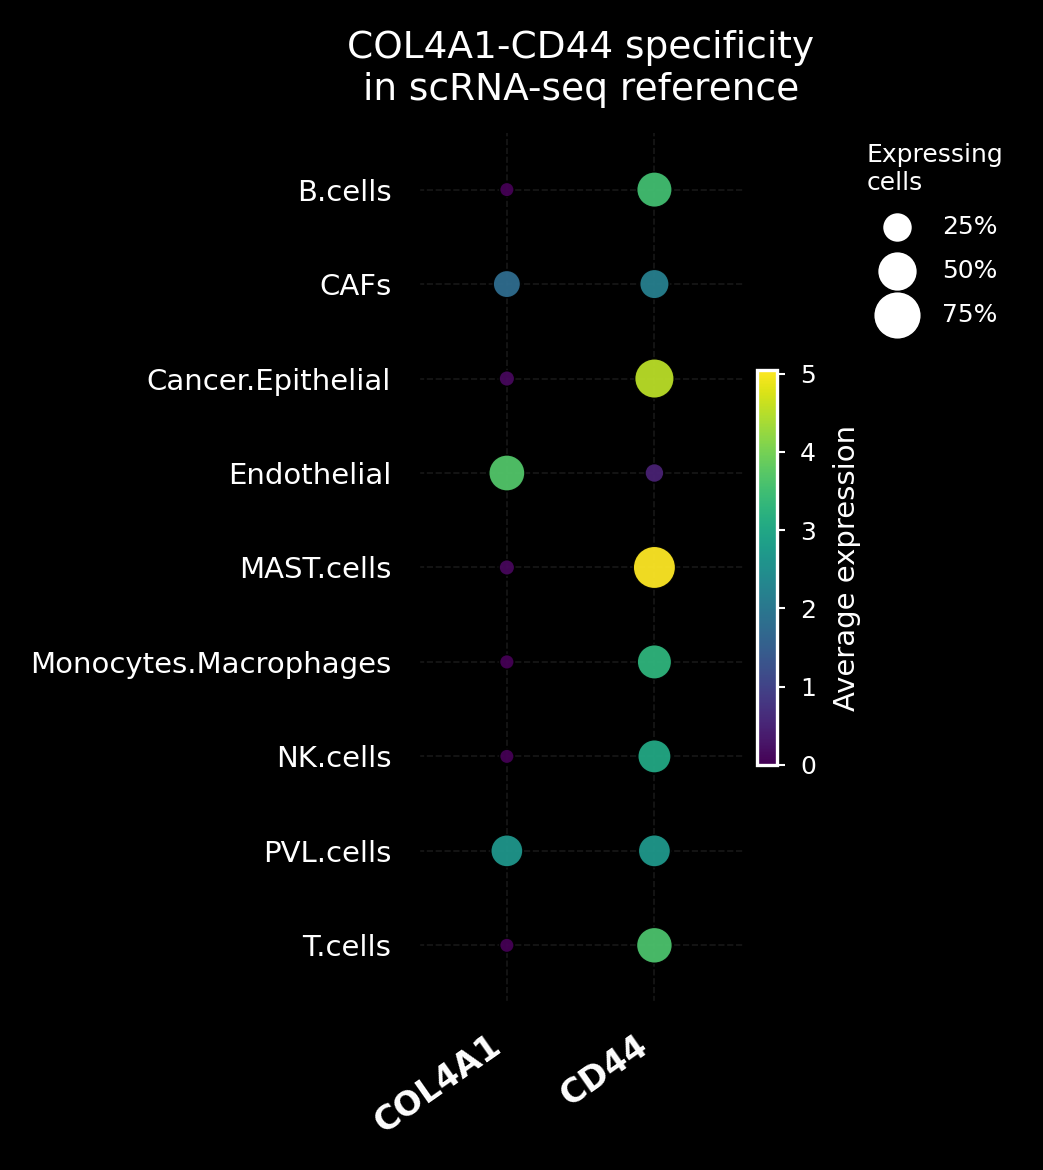

In [21]:
# ======================================================================
# MODULE 6. SC-REF LR SPECIFICITY
# ======================================================================
from matplotlib.colors import Normalize

genes_use = [ligand, receptor]
expr_threshold = 0
save_pdf = os.path.join(CCI_OUT_DIR,f"sc_ref_{ligand}_{receptor}_celltype_dotplot.pdf")

# ============================================================
# Helpers
# ============================================================

def get_gene_vector(adata, gene):
    gene = str(gene).upper()
    if gene not in adata.var_names:
        raise ValueError(f"{gene} not found in sc_ref.var_names.")

    X = adata[:, gene].X
    if sp.issparse(X):
        vals = np.asarray(X.toarray()).reshape(-1)
    else:
        vals = np.asarray(X).reshape(-1)

    vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
    return vals.astype(float)

# ============================================================
# Load scRNA reference
# ============================================================

sc_ref = sc.read(SC_REF_FILE)
sc_ref.obs["cell_type"] = sc_ref.obs["cell_type"].astype(str)
sc_ref.var_names = sc_ref.var_names.astype(str).str.upper()

if sc_ref.var_names.duplicated().sum() > 0:
    print(
        "Duplicated genes after upper-case conversion:",
        sc_ref.var_names.duplicated().sum()
    )
    sc_ref = sc_ref[:, ~sc_ref.var_names.duplicated()].copy()

genes_use = [g.upper() for g in genes_use]
genes_present = [g for g in genes_use if g in sc_ref.var_names]

if len(genes_present) == 0:
    raise ValueError(f"Neither {ligand} nor {receptor} was found in sc-ref.")

missing = sorted(set(genes_use) - set(genes_present))
if len(missing) > 0:
    print("Missing genes:", missing)

sc_ref = sc_ref[:, genes_present].copy()
if not sc_ref_already_log_norm:
    sc.pp.normalize_total(sc_ref, target_sum=1e4)
    sc.pp.log1p(sc_ref)
else:
    print("Use existing log-normalized scRNA reference.")

celltype_order_use = [ct for ct in label_uniq if ct in sc_ref.obs["cell_type"].astype(str).unique()]

# ============================================================
# Compute average expression and expressing fraction
# ============================================================
rows = []
labels = sc_ref.obs["cell_type"].astype(str).values

for gene in genes_present:
    vals = get_gene_vector(sc_ref, gene)

    for ct in celltype_order_use:
        idx = labels == ct

        if idx.sum() == 0:
            continue

        vals_ct = vals[idx]

        avg_expr = np.mean(vals_ct)
        pct_expr = np.mean(vals_ct > expr_threshold) * 100

        rows.append({
            "gene": gene,
            "cell_type": ct,
            "avg_expr": avg_expr,
            "pct_expr": pct_expr,
            "n_cells": int(idx.sum())
        })

dot_df = pd.DataFrame(rows)
dot_df["gene"] = pd.Categorical(dot_df["gene"],categories=genes_present,ordered=True)
dot_df["cell_type"] = pd.Categorical(dot_df["cell_type"],categories=celltype_order_use,ordered=True)
dot_df = dot_df.sort_values(["gene", "cell_type"]).reset_index(drop=True)

# ============================================================
# Plot cell type × gene dotplot
# ============================================================

gene_order = [ligand, receptor]
gene_order = [g for g in gene_order if g in genes_present]

x_map = {gene: i for i, gene in enumerate(gene_order)}

y_map = {
    ct: len(celltype_order_use) - 1 - i
    for i, ct in enumerate(celltype_order_use)
}

dot_df["x"] = dot_df["gene"].astype(str).map(x_map)
dot_df["y"] = dot_df["cell_type"].astype(str).map(y_map)

vmin = 0
vmax = np.nanpercentile(dot_df["avg_expr"].values, 98)
if vmax <= 0:
    vmax = dot_df["avg_expr"].max()
if vmax <= 0:
    vmax = 1.0
norm = Normalize(vmin=vmin, vmax=vmax)

min_size = 12
max_size = 170
pct = dot_df["pct_expr"].values
size_vals = min_size + (pct / 100.0) * (max_size - min_size)
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
scat = ax.scatter(
    dot_df["x"].astype(float),
    dot_df["y"].astype(float),
    s=size_vals,
    c=dot_df["avg_expr"].astype(float),
    cmap="viridis",
    norm=norm,
    edgecolors="black",
    linewidths=0.35,
    alpha=0.95,
    zorder=3
)

ax.set_xticks(range(len(gene_order)))
ax.set_xticklabels(
    gene_order,
    rotation=35,
    ha="right",
    fontsize=8,
    fontweight="bold"
)
ax.set_yticks(range(len(celltype_order_use)))
ax.set_yticklabels(
    celltype_order_use[::-1],
    fontsize=7
)

ax.set_xlim(-0.6, len(gene_order) - 0.4)
ax.set_ylim(-0.6, len(celltype_order_use) - 0.4)

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title(f"{ligand}-{receptor} specificity\nin scRNA-seq reference",fontsize=9,pad=8)
ax.grid(axis="both",linestyle="--",linewidth=0.4,alpha=0.18,color="gray",zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

ax.tick_params(axis="both",which="major",width=0.8,length=3,color="black")
cbar = plt.colorbar(ScalarMappable(norm=norm, cmap="viridis"),ax=ax,fraction=0.055,pad=0.04)
cbar.set_label("Average expression", fontsize=7)
cbar.ax.tick_params(labelsize=6, width=0.5, length=2)

legend_pcts = [25, 50, 75]
legend_handles = []

for p in legend_pcts:
    s = min_size + (p / 100.0) * (max_size - min_size)
    h = ax.scatter(
        [],
        [],
        s=s,
        facecolors="white",
        edgecolors="black",
        linewidths=0.35,
        label=f"{p}%"
    )
    legend_handles.append(h)

leg = ax.legend(
    handles=legend_handles,
    title="Expressing\ncells",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    loc="upper left",
    bbox_to_anchor=(1.35, 1.0),
    borderaxespad=0.0,
    handletextpad=0.8,
    labelspacing=0.8
)

plt.tight_layout()

plt.savefig(save_pdf, dpi=300, bbox_inches="tight")
plt.show()


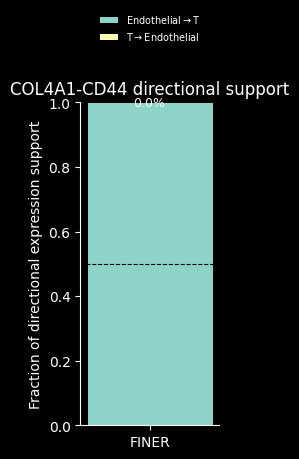

In [25]:
# ======================================================================
# MODULE 7. REPRESENTATIVE LR DIRECTIONAL SUPPORT SCORE
# ======================================================================

from scipy.spatial import cKDTree

support_radius = 188.6 / 2
support_n_bootstrap = 2000
support_bootstrap_seed = 12345
support_eps_relative = 1e-8

endothelial_labels = ["Endothelial"]
tcell_labels = ["T.cells"]

support_save_pdf = os.path.join(CCI_OUT_DIR,f"{ligand}_{receptor}_directional_support_fraction_FINER.pdf")

# ============================================================
# Helpers
# ============================================================

def make_label_mask(values, allowed_labels):
    allowed = {str(x).strip().casefold()for x in allowed_labels}
    cleaned = (pd.Series(values).astype(str).str.strip().str.casefold())
    return cleaned.isin(allowed).to_numpy()


def extract_gene_expression(
    adata,
    gene,
    clip_negative=True,
):
    gene = str(gene).upper()

    var_names = np.asarray([str(x) for x in adata.var_names],dtype=str)
    upper_names = np.asarray([x.upper() for x in var_names],dtype=str)
    matches = np.where(upper_names == gene)[0]

    if len(matches) == 0:
        raise KeyError(
            f"{gene} not found in adata.var_names"
        )

    if len(matches) > 1:
        print(
            f"Warning: {gene} matched {len(matches)} entries. "
            f"Using the first one: {var_names[matches[0]]}"
        )

    idx = int(matches[0])
    x = adata.X[:, idx]

    if sp.issparse(x):
        x = x.toarray().ravel()
    else:
        x = np.asarray(x).ravel()

    x = x.astype(float)

    if not np.all(np.isfinite(x)):
        raise ValueError(
            f"Non-finite expression values found for {gene}"
        )

    if clip_negative:
        x = np.clip(x,a_min=0.0,a_max=None,)

    return x


def directional_log_ratio(
    forward,
    reverse,
    eps_rel=1e-8,
):
    scale = max(float(forward),float(reverse),)

    if scale <= 0:
        return np.nan

    eps = eps_rel * scale

    return np.log2((forward + eps) /(reverse + eps))


def compute_COL4A1_CD44_support(
    adata,
    method_name,
    radius,
    cell_type_col,
    n_boot=2000,
    seed=12345,
):
    if "spatial" not in adata.obsm:
        raise KeyError(
            f"{method_name}: spatial coordinates missing."
        )

    coords = np.asarray(adata.obsm["spatial"],dtype=float)[:, :2]
    valid = np.all(np.isfinite(coords),axis=1)
    cell_types = (adata.obs[cell_type_col].astype(str).to_numpy())

    endo_mask = make_label_mask(cell_types,endothelial_labels,)
    t_mask = make_label_mask(cell_types,tcell_labels,)

    endo_mask &= valid
    t_mask &= valid

    endo_idx = np.where(endo_mask)[0]
    t_idx = np.where(t_mask)[0]

    COL4A1 = extract_gene_expression(adata,"COL4A1",clip_negative=True)
    CD44 = extract_gene_expression(adata,"CD44",clip_negative=True,)

    endo_coords = coords[endo_idx]
    t_coords = coords[t_idx]

    COL4A1_endo = COL4A1[endo_idx]
    CD44_endo = CD44[endo_idx]

    COL4A1_t = COL4A1[t_idx]
    CD44_t = CD44[t_idx]

    # --------------------------------------------------------
    # Native Endothelial--T adjacency
    # --------------------------------------------------------
    endo_tree = cKDTree(endo_coords)
    t_tree = cKDTree(t_coords)
    endo_to_t = endo_tree.query_ball_tree(t_tree,r=radius)
    t_to_endo = t_tree.query_ball_tree(endo_tree,r=radius)

    # --------------------------------------------------------
    # Endothelial COL4A1 -> T-cell CD44
    # --------------------------------------------------------
    forward_contributions = []

    for endo_local_idx, neighbours in enumerate(endo_to_t):
        if len(neighbours) == 0:
            continue

        mean_target_CD44 = np.mean(CD44_t[neighbours])
        contribution = (COL4A1_endo[endo_local_idx] * mean_target_CD44)
        forward_contributions.append(contribution)

    # --------------------------------------------------------
    # T-cell COL4A1 -> Endothelial CD44
    # --------------------------------------------------------
    reverse_contributions = []

    for t_local_idx, neighbours in enumerate(t_to_endo):
        if len(neighbours) == 0:
            continue
        mean_target_CD44 = np.mean(CD44_endo[neighbours])
        contribution = (COL4A1_t[t_local_idx] * mean_target_CD44)
        reverse_contributions.append(contribution)

    forward_contributions = np.asarray(forward_contributions,dtype=float,)
    reverse_contributions = np.asarray(reverse_contributions,dtype=float,)

    if len(forward_contributions) == 0:
        raise ValueError(
            f"{method_name}: no endothelial cells "
            f"with T neighbours within radius {radius}."
        )

    if len(reverse_contributions) == 0:
        raise ValueError(
            f"{method_name}: no T cells "
            f"with endothelial neighbours within radius {radius}."
        )

    forward_support = np.mean(forward_contributions)
    reverse_support = np.mean(reverse_contributions)
    direction_score = directional_log_ratio(forward_support,reverse_support,eps_rel=support_eps_relative)

    # --------------------------------------------------------
    # Directional fractions
    # --------------------------------------------------------
    total = (forward_support + reverse_support)
    forward_fraction = (forward_support / total if total > 0 else np.nan)
    reverse_fraction = (reverse_support / total if total > 0 else np.nan)

    # --------------------------------------------------------
    # Bootstrap
    # --------------------------------------------------------
    rng = np.random.default_rng(seed)
    boot_scores = []

    for _ in range(n_boot):
        forward_boot = np.mean(
            rng.choice(
                forward_contributions,
                size=len(forward_contributions),
                replace=True,
            )
        )
        reverse_boot = np.mean(
            rng.choice(reverse_contributions,size=len(reverse_contributions),replace=True)
        )
        boot_scores.append(directional_log_ratio(forward_boot,reverse_boot))

    boot_scores = np.asarray(boot_scores)
    boot_scores = boot_scores[np.isfinite(boot_scores)]
    ci_low, ci_high = np.quantile(boot_scores,[0.025, 0.975])

    return {
        "method": method_name,
        "radius": radius,
        "n_Endothelial": len(endo_idx),
        "n_T": len(t_idx),
        "n_Endothelial_with_T_neighbour":len(forward_contributions),
        "n_T_with_Endothelial_neighbour":len(reverse_contributions),
        "Endothelial_to_T_support":forward_support,
        "T_to_Endothelial_support":reverse_support,
        "Endothelial_to_T_fraction":forward_fraction,
        "T_to_Endothelial_fraction":reverse_fraction,
        "directional_log2_ratio":direction_score,
        "ci_low_95":ci_low,
        "ci_high_95":ci_high,
    }


# ============================================================
# Run 
# ============================================================
support_lr_genes_common = pd.read_csv(COMMON_GENE_ALL_FILE,index_col=0)["0"].astype(str).str.upper().values
support_adata = sc.read_h5ad(FINER_FILE)

support_adata.var_names = (support_adata.var_names.astype(str).str.upper())
support_shared_genes = [g for g in support_lr_genes_common if g in support_adata.var_names]
support_adata = support_adata[:,support_shared_genes].copy()

# Preserve the original preprocessing exactly.
sc.pp.normalize_total(support_adata,target_sum=1e4)
sc.pp.log1p(support_adata)

support_result = compute_COL4A1_CD44_support(
    adata=support_adata,
    method_name=METHOD_NAME,
    radius=support_radius,
    cell_type_col="cell_type",
    n_boot=support_n_bootstrap,
    seed=support_bootstrap_seed,
)

support_results_df = pd.DataFrame([support_result])

# ============================================================
# Plot directional support fractions
# ============================================================
plot_df = support_results_df.copy()
x = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(2.2, 6))

ax.bar(
    x,
    plot_df["Endothelial_to_T_fraction"],
    width=0.62,
    label=r"Endothelial$\rightarrow$T",
    edgecolor="black",
    linewidth=0.7,
)

ax.bar(
    x,
    plot_df["T_to_Endothelial_fraction"],
    bottom=plot_df["Endothelial_to_T_fraction"],
    width=0.62,
    label=r"T$\rightarrow$Endothelial",
    edgecolor="black",
    linewidth=0.7,
)

ax.axhline(0.5,linestyle="--",linewidth=0.8,color="black")

for idx, row in plot_df.iterrows():
    reverse_fraction = (row["T_to_Endothelial_fraction"])
    y = (row["Endothelial_to_T_fraction"]+ reverse_fraction / 2)
    ax.text(idx,y,f"{reverse_fraction * 100:.1f}%",ha="center",va="center",fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["method"])
ax.set_ylim(0, 1)
ax.set_ylabel("Fraction of directional expression support")
ax.set_title(f"{ligand}-{receptor} directional support")
ax.legend(
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.16),
    ncol=1,
    fontsize=7,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.82])
fig.savefig(support_save_pdf,dpi=300,bbox_inches="tight")

plt.show()
plt.close(fig)

